# Importation de la base donne

In [113]:
from pymongo import MongoClient
import pandas as pd

# Connexion à MongoDB en local (par défaut sur localhost:27017)
client = MongoClient('mongodb://localhost:27017/')

# Sélection de la base de données
db = client['autoscout24_db']

# Sélection de la collection
collection = db['annonces']

# Récupération de toutes les données de la collection
donnees = list(collection.find())

# Conversion en DataFrame pandas pour une meilleure visualisation
df = pd.DataFrame(donnees)
df

,_id,Marque,Modèle,Carrosserie,Etat,Sieges,Portes,Annonce_ID,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois
0,6882d0cef0900db40c84f1fd,Mercedes-Benz,200,Break,Occasion,5,5,NON,2010,Boîte manuelle,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0
1,6882d0edf0900db40c84f1fe,Mercedes-Benz,190,Berline,Occasion,4,4,NON,1990,Boîte manuelle,Essence,Blauschwarz,Métallisé,Noir,269000,112500,234,463,0,0
2,6882d0f0f0900db40c84f1ff,Mercedes-Benz,190,Autres,Occasion,2,3,2158,1959,Boîte manuelle,Essence,JAUNE,NON,Noir,139500,39361,106,0,0,0
3,6882d104f0900db40c84f200,Mercedes-Benz,300,Break,Occasion,0,0,NON,1990,Boîte automatique,Diesel,NON,NON,NON,12000,318000,0,0,0,0
4,6882d106f0900db40c84f201,Mercedes-Benz,300,Berline,Occasion,0,0,NON,1976,Boîte automatique,Diesel,NON,NON,NON,8800,272000,80,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10238,68833800f0900db40c8519fb,BMW,M6,Berline,Occasion,5,4,A9816,2023,Boîte automatique,Electrique,M Carbonschwarz métallisé,NON,NON,76900,11300,345,0,0,60
10239,68833801f0900db40c8519fc,BMW,M6,SUV/4x4/Pick-Up,Occasion,5,5,Q24252,2023,Boîte automatique,Electrique,Sophistograu métallisé,NON,NON,89900,19000,548,0,0,24
10240,68833813f0900db40c8519fd,BMW,M5,Break,Occasion,5,5,1936749,2025,Boîte automatique,Essence,Teinte carross mét BMW Ind/Toi,Métallisé,NON,174890,9900,594,395,39,0
10241,68833818f0900db40c8519fe,BMW,M5,SUV/4x4/Pick-Up,Occasion,5,5,SS20219832,2024,Boîte automatique,Essence,Saphirscwharz métallisé,NON,NON,108900,10357,318,998,37,24


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10243 entries, 0 to 10242
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   _id                10243 non-null  object
 1   Marque             10243 non-null  object
 2   Modèle             10243 non-null  object
 3   Carrosserie        10243 non-null  object
 4   Etat               10243 non-null  object
 5   Sieges             10243 non-null  int64 
 6   Portes             10243 non-null  int64 
 7   Annonce_ID         10243 non-null  object
 8   Annee              10243 non-null  int64 
 9   Transmission       10243 non-null  object
 10  Carburant          10243 non-null  object
 11  Couleur_originale  10243 non-null  object
 12  Type_peinture      10243 non-null  object
 13  Couleur_interieur  10243 non-null  object
 14  Prix €             10243 non-null  int64 
 15  Kilometrage_km     10243 non-null  int64 
 16  Puissance_CH       10243 non-null  int64

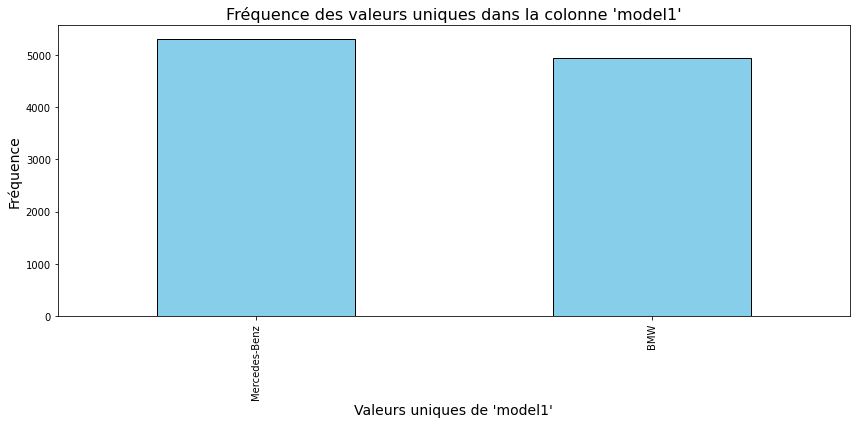

In [115]:
import matplotlib.pyplot as plt

# Compter les occurrences de chaque valeur unique dans la colonne 'model1'
model1_counts = df['Marque'].value_counts()

# Créer un graphique en barres
plt.figure(figsize=(12, 6))
model1_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Ajouter des titres et des labels
plt.title("Fréquence des valeurs uniques dans la colonne 'model1'", fontsize=16)
plt.xlabel("Valeurs uniques de 'model1'", fontsize=14)
plt.ylabel("Fréquence", fontsize=14)

# Rotation des labels pour une meilleure lisibilité
plt.xticks(rotation=90)

# Afficher le graphique
plt.tight_layout()
plt.show()

In [116]:
df.isnull().sum()

_id                  0
Marque               0
Modèle               0
Carrosserie          0
Etat                 0
Sieges               0
Portes               0
Annonce_ID           0
Annee                0
Transmission         0
Carburant            0
Couleur_originale    0
Type_peinture        0
Couleur_interieur    0
Prix €               0
Kilometrage_km       0
Puissance_CH         0
Cylindrée_cm³        0
CO2_g/km             0
Garantie_mois        0
dtype: int64

### on verefie les types de donne et on les transforme en int ou bien float , et on applique les differentes modification sur

In [117]:
df.dtypes

_id                  object
Marque               object
Modèle               object
Carrosserie          object
Etat                 object
Sieges                int64
Portes                int64
Annonce_ID           object
Annee                 int64
Transmission         object
Carburant            object
Couleur_originale    object
Type_peinture        object
Couleur_interieur    object
Prix €                int64
Kilometrage_km        int64
Puissance_CH          int64
Cylindrée_cm³         int64
CO2_g/km              int64
Garantie_mois         int64
dtype: object

In [118]:
Q1 = df['Prix €'].quantile(0.25)
Q3 = df['Prix €'].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

# Détection
outliers = df[(df['Prix €'] < borne_basse) | (df['Prix €'] > borne_haute)]

# Suppression
df= df[(df['Prix €'] >= borne_basse) & (df['Prix €'] <= borne_haute)]
df

,_id,Marque,Modèle,Carrosserie,Etat,Sieges,Portes,Annonce_ID,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois
0,6882d0cef0900db40c84f1fd,Mercedes-Benz,200,Break,Occasion,5,5,NON,2010,Boîte manuelle,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0
3,6882d104f0900db40c84f200,Mercedes-Benz,300,Break,Occasion,0,0,NON,1990,Boîte automatique,Diesel,NON,NON,NON,12000,318000,0,0,0,0
4,6882d106f0900db40c84f201,Mercedes-Benz,300,Berline,Occasion,0,0,NON,1976,Boîte automatique,Diesel,NON,NON,NON,8800,272000,80,0,0,0
5,6882d119f0900db40c84f202,Mercedes-Benz,300,Cabriolet,Occasion,4,2,VN0013029,2025,Boîte automatique,Autres,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24
7,6882d12df0900db40c84f204,Mercedes-Benz,300,Coupé,Occasion,2,3,NON,1993,Avant,Essence,Argent,NON,Brun,6800,65000,232,962,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10232,688337d3f0900db40c8519f5,BMW,850,Coupé,Occasion,5,4,14236,2019,Boîte automatique,Essence,Carbonschwarz,Métallisé,NON,61900,95900,538,395,0,24
10233,688337d5f0900db40c8519f6,BMW,850,Coupé,Occasion,4,2,2533,1991,Boîte manuelle,Essence,GRIS,NON,Bleu,45000,92000,305,988,0,6
10235,688337e9f0900db40c8519f8,BMW,840,Coupé,Occasion,4,2,bay1-FC-834-RX_2410039,2018,4x4,Diesel,Carbonschwarz (3) mútal,NON,NON,48999,126923,0,993,0,0
10236,688337e9f0900db40c8519f9,BMW,840,Coupé,Occasion,5,4,2411002,2021,Boîte automatique,Essence,BMW Ind Tanzanite Blue,NON,NON,59890,93541,339,998,197,24


In [119]:
Q1 = df['Kilometrage_km'].quantile(0.25)
Q3 = df['Kilometrage_km'].quantile(0.75)
IQR = Q3 - Q1

borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

# Détection
outliers = df[(df['Kilometrage_km'] < borne_basse) | (df['Kilometrage_km'] > borne_haute)]

# Suppression
df= df[(df['Kilometrage_km'] >= borne_basse) & (df['Kilometrage_km'] <= borne_haute)]
df

,_id,Marque,Modèle,Carrosserie,Etat,Sieges,Portes,Annonce_ID,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois
0,6882d0cef0900db40c84f1fd,Mercedes-Benz,200,Break,Occasion,5,5,NON,2010,Boîte manuelle,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0
5,6882d119f0900db40c84f202,Mercedes-Benz,300,Cabriolet,Occasion,4,2,VN0013029,2025,Boîte automatique,Autres,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24
7,6882d12df0900db40c84f204,Mercedes-Benz,300,Coupé,Occasion,2,3,NON,1993,Avant,Essence,Argent,NON,Brun,6800,65000,232,962,5,0
8,6882d130f0900db40c84f205,Mercedes-Benz,300,SUV/4x4/Pick-Up,Occasion,5,5,NON,2021,Avant,NON,Bleu,NON,Brun,51990,50100,211,0,0,12
10,6882d144f0900db40c84f207,Mercedes-Benz,300,Cabriolet,Ancêtre,4,2,NON,1993,Boîte automatique,Essence,Noir,NON,Brun,19000,259167,231,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10232,688337d3f0900db40c8519f5,BMW,850,Coupé,Occasion,5,4,14236,2019,Boîte automatique,Essence,Carbonschwarz,Métallisé,NON,61900,95900,538,395,0,24
10233,688337d5f0900db40c8519f6,BMW,850,Coupé,Occasion,4,2,2533,1991,Boîte manuelle,Essence,GRIS,NON,Bleu,45000,92000,305,988,0,6
10235,688337e9f0900db40c8519f8,BMW,840,Coupé,Occasion,4,2,bay1-FC-834-RX_2410039,2018,4x4,Diesel,Carbonschwarz (3) mútal,NON,NON,48999,126923,0,993,0,0
10236,688337e9f0900db40c8519f9,BMW,840,Coupé,Occasion,5,4,2411002,2021,Boîte automatique,Essence,BMW Ind Tanzanite Blue,NON,NON,59890,93541,339,998,197,24


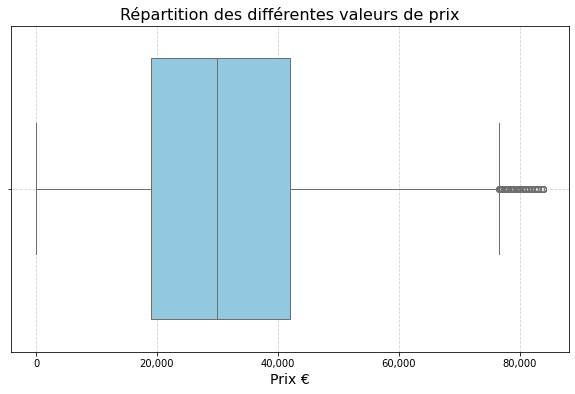

In [120]:
import seaborn as sns
from matplotlib import ticker

# Créer un graphique en boîte pour afficher les différentes valeurs de prix
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Prix €'], color='skyblue')

# Ajouter des titres et des labels
plt.title("Répartition des différentes valeurs de prix", fontsize=16)
plt.xlabel("Prix €", fontsize=14)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
# Afficher le graphique
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

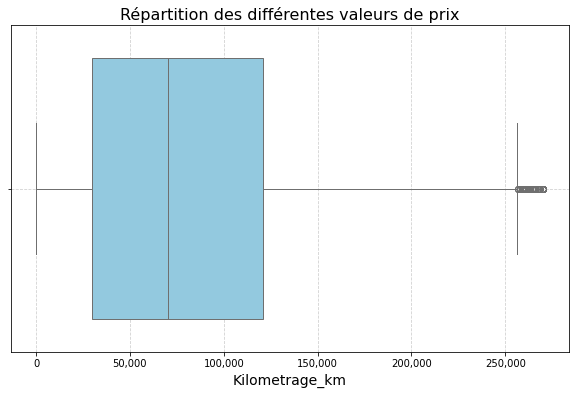

In [121]:
import seaborn as sns
from matplotlib import ticker

# Créer un graphique en boîte pour afficher les différentes valeurs de prix
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Kilometrage_km'], color='skyblue')

# Ajouter des titres et des labels
plt.title("Répartition des différentes valeurs de prix", fontsize=16)
plt.xlabel("Kilometrage_km", fontsize=14)
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
# Afficher le graphique
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

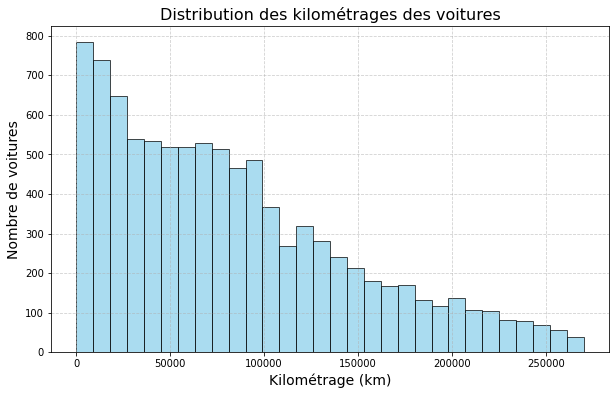

In [122]:
import matplotlib.pyplot as plt

# Créer la figure
plt.figure(figsize=(10, 6))

# Tracer un histogramme pour visualiser la distribution des kilométrages
plt.hist(df['Kilometrage_km'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les titres et labels
plt.title("Distribution des kilométrages des voitures", fontsize=16)
plt.xlabel("Kilométrage (km)", fontsize=14)
plt.ylabel("Nombre de voitures", fontsize=14)

# Ajouter une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.6)

# Afficher le graphique
plt.show()


In [123]:
df['Garantie_mois'] = df['Garantie_mois'].fillna('0')
df['Garantie_mois'].unique()


C:\Users\dell\AppData\Local\Temp\ipykernel_7272\4183510189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Garantie_mois'] = df['Garantie_mois'].fillna('0')


array([ 0, 24, 12,  6,  3, 20,  8, 36, 23,  9, 60, 22, 48], dtype=int64)

In [124]:
df = df.dropna(subset=['Carburant'])

carburant_mapping = {
    'Super 95': 'Essence',
    'Super E10 95': 'Essence',
    'Super Plus 98': 'Essence'
}
df['Carburant'] = df['Carburant'].replace(carburant_mapping)


In [125]:
transmission_mapping = {'NaN':7,
    'Boîte manuelle': 0,
    'Boîte automatique': 1,
    'Avant': 3 ,  'Arrière': 4, '4x4': 5 , 'Semi-automatique': 6}

df['Transmission']=df['Transmission'].map(transmission_mapping)
df['Transmission'] = df['Transmission'].fillna(7).astype(int)
df = df[df['Transmission'].isin([0, 1])]
df['Transmission'].value_counts()

Transmission
1    5490
0    1042
Name: count, dtype: int64

In [126]:
df.drop(columns=['_id'], inplace=True)
df.drop(columns=['Annonce_ID'], inplace=True)
df = df[df['Annee'] >= 2000]



In [127]:
df = pd.get_dummies(df, columns=['Marque'], drop_first=True)

df

,Modèle,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois,Marque_Mercedes-Benz
0,200,Break,Occasion,5,5,2010,0,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0,True
5,300,Cabriolet,Occasion,4,2,2025,1,Autres,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24,True
33,350,Cabriolet,Occasion,4,2,2014,1,Diesel,NOIR,NON,NON,38490,26800,256,987,0,12,True
76,280,Berline,Occasion,5,4,2006,1,Diesel,NON,Autres,NON,6000,196000,185,222,0,0,True
91,250,SUV/4x4/Pick-Up,Occasion,7,5,2024,1,Electrique,Noir,NON,NON,45699,11249,0,0,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10225,630,Autres,Occasion,0,5,2018,1,Diesel,NON,NON,NON,39990,78000,0,0,0,0,False
10226,630,Coupé,Occasion,0,2,2008,0,Essence,Noir,NON,NON,20990,82500,272,996,188,0,False
10232,850,Coupé,Occasion,5,4,2019,1,Essence,Carbonschwarz,Métallisé,NON,61900,95900,538,395,0,24,False
10236,840,Coupé,Occasion,5,4,2021,1,Essence,BMW Ind Tanzanite Blue,NON,NON,59890,93541,339,998,197,24,False


In [128]:
df.shape

(6332, 18)

In [129]:
# Transformer uniquement les colonnes booléennes en entiers (True -> 1, False -> 0)
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)

# Afficher les premières lignes pour vérifier
df.head()


,Modèle,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois,Marque_Mercedes-Benz
0,200,Break,Occasion,5,5,2010,0,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0,1
5,300,Cabriolet,Occasion,4,2,2025,1,Autres,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24,1
33,350,Cabriolet,Occasion,4,2,2014,1,Diesel,NOIR,NON,NON,38490,26800,256,987,0,12,1
76,280,Berline,Occasion,5,4,2006,1,Diesel,NON,Autres,NON,6000,196000,185,222,0,0,1
91,250,SUV/4x4/Pick-Up,Occasion,7,5,2024,1,Electrique,Noir,NON,NON,45699,11249,0,0,0,0,1


In [130]:
# Calculer la moyenne de la variable cible (Prix (€)) pour chaque valeur unique de model2
model2_target_mean = df.groupby('Modèle')['Prix €'].mean()

# Remplacer les valeurs de la colonne model2 par les moyennes correspondantes
df['Modèle'] = df['Modèle'].map(model2_target_mean)

# Supprimer la colonne originale si elle n'est plus nécessaire
df= df.drop(columns=['Modèle'])

# Afficher les premières lignes pour vérifier
df.head()

,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois,Marque_Mercedes-Benz
0,Break,Occasion,5,5,2010,0,Diesel,Gris,Métallisé,Gris,1100,247570,75,0,0,0,1
5,Cabriolet,Occasion,4,2,2025,1,Autres,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24,1
33,Cabriolet,Occasion,4,2,2014,1,Diesel,NOIR,NON,NON,38490,26800,256,987,0,12,1
76,Berline,Occasion,5,4,2006,1,Diesel,NON,Autres,NON,6000,196000,185,222,0,0,1
91,SUV/4x4/Pick-Up,Occasion,7,5,2024,1,Electrique,Noir,NON,NON,45699,11249,0,0,0,0,1


In [131]:
from sklearn.preprocessing import LabelEncoder

# Initialiser le LabelEncoder
label_encoder_carburant = LabelEncoder()
df['Carburant'] = df['Carburant'].map({'Essence': 0, 'Diesel': 1})


# Afficher les premières lignes pour vérifier
df.head()

,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,CO2_g/km,Garantie_mois,Marque_Mercedes-Benz
0,Break,Occasion,5,5,2010,0,1.0,Gris,Métallisé,Gris,1100,247570,75,0,0,0,1
5,Cabriolet,Occasion,4,2,2025,1,NaN,Blanc opalithe brillant MANUFA,NON,NON,79900,3500,262,999,165,24,1
33,Cabriolet,Occasion,4,2,2014,1,1.0,NOIR,NON,NON,38490,26800,256,987,0,12,1
76,Berline,Occasion,5,4,2006,1,1.0,NON,Autres,NON,6000,196000,185,222,0,0,1
91,SUV/4x4/Pick-Up,Occasion,7,5,2024,1,NaN,Noir,NON,NON,45699,11249,0,0,0,0,1


In [132]:
# Supprimer la colonne 'CO2'
df = df.drop(columns=['CO2_g/km'])

# Supprimer les lignes où la colonne 'Carburant' contient des valeurs vides
df = df.dropna(subset=['Carburant'])

# Afficher les premières lignes pour vérifier
df.head()

,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,Garantie_mois,Marque_Mercedes-Benz
0,Break,Occasion,5,5,2010,0,1.0,Gris,Métallisé,Gris,1100,247570,75,0,0,1
33,Cabriolet,Occasion,4,2,2014,1,1.0,NOIR,NON,NON,38490,26800,256,987,12,1
76,Berline,Occasion,5,4,2006,1,1.0,NON,Autres,NON,6000,196000,185,222,0,1
92,Autres,Occasion,0,2,2018,1,0.0,Blanc,NON,NON,34900,100300,0,0,0,1
126,Autres,Occasion,0,5,2019,1,0.0,Gris,NON,NON,30990,48195,190,0,0,1


In [133]:
df

,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,Garantie_mois,Marque_Mercedes-Benz
0,Break,Occasion,5,5,2010,0,1.0,Gris,Métallisé,Gris,1100,247570,75,0,0,1
33,Cabriolet,Occasion,4,2,2014,1,1.0,NOIR,NON,NON,38490,26800,256,987,12,1
76,Berline,Occasion,5,4,2006,1,1.0,NON,Autres,NON,6000,196000,185,222,0,1
92,Autres,Occasion,0,2,2018,1,0.0,Blanc,NON,NON,34900,100300,0,0,0,1
126,Autres,Occasion,0,5,2019,1,0.0,Gris,NON,NON,30990,48195,190,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10223,Cabriolet,Occasion,0,2,2006,1,0.0,Vert,NON,NON,22990,85000,258,996,6,0
10225,Autres,Occasion,0,5,2018,1,1.0,NON,NON,NON,39990,78000,0,0,0,0
10226,Coupé,Occasion,0,2,2008,0,0.0,Noir,NON,NON,20990,82500,272,996,0,0
10232,Coupé,Occasion,5,4,2019,1,0.0,Carbonschwarz,Métallisé,NON,61900,95900,538,395,24,0


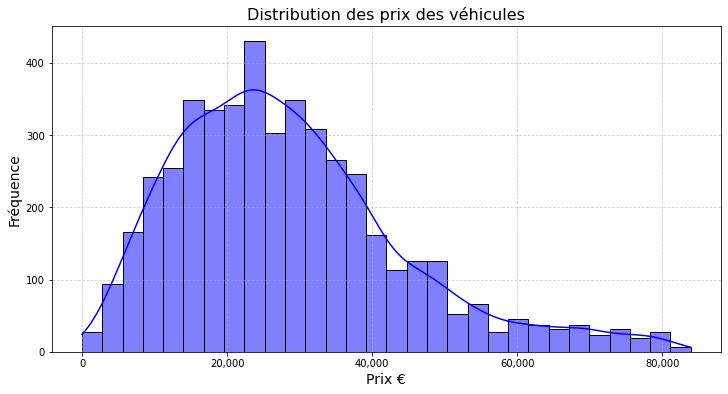

In [134]:
import seaborn as sns

import matplotlib.pyplot as plt

# Créer la figure
plt.figure(figsize=(12, 6))

# Tracer la distribution des prix
sns.histplot(df['Prix €'], kde=True, color='blue', bins=30)

# Ajouter des titres et des labels
plt.title("Distribution des prix des véhicules", fontsize=16)
plt.xlabel("Prix €", fontsize=14)
plt.ylabel("Fréquence", fontsize=14)

# Formatter l'axe des x pour éviter la notation scientifique
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Afficher le graphique
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

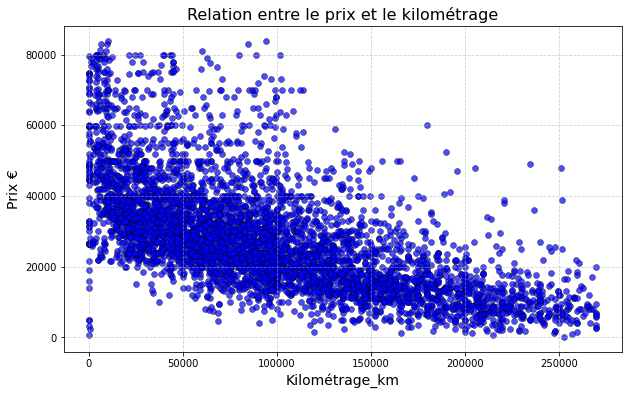

In [135]:
import seaborn as sns

import matplotlib.pyplot as plt

# Créer la figure
plt.figure(figsize=(10, 6))

# Tracer un nuage de points pour visualiser la relation entre le prix et le kilométrage
sns.scatterplot(x=df['Kilometrage_km'], y=df['Prix €'], alpha=0.7, color='blue', edgecolor='black')

# Ajouter les titres et labels
plt.title("Relation entre le prix et le kilométrage", fontsize=16)
plt.xlabel("Kilométrage_km", fontsize=14)
plt.ylabel("Prix €", fontsize=14)

# Ajouter une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.6)

# Afficher le graphique
plt.show()

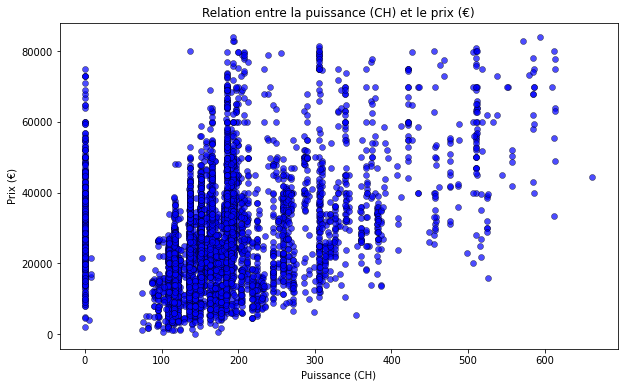

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer la figure
plt.figure(figsize=(10, 6))

# Tracer un nuage de points pour visualiser la relation entre la puissance et le prix
sns.scatterplot(
    x=df['Puissance_CH'],
    y=df['Prix €'],
    alpha=0.7,
    color='blue',
    edgecolor='black'
)

# Ajouter un titre et des labels
plt.title('Relation entre la puissance (CH) et le prix (€)')
plt.xlabel('Puissance (CH)')
plt.ylabel('Prix (€)')

# Afficher la figure
plt.show()


C:\Users\dell\AppData\Local\Temp\ipykernel_7272\439219306.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prix_moyen_par_carburant.index, y=prix_moyen_par_carburant.values, palette="viridis")


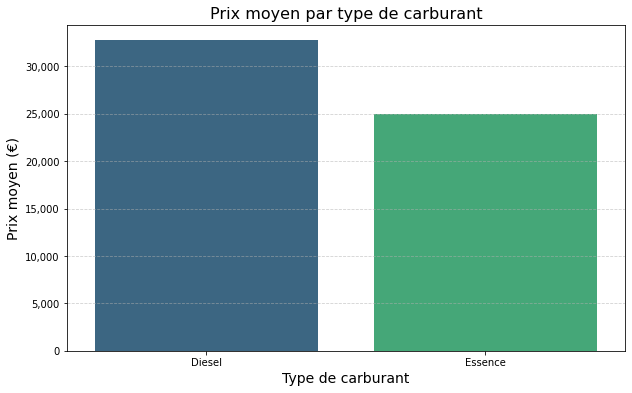

In [137]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculer le prix moyen par type de carburant
prix_moyen_par_carburant = df.groupby('Carburant')['Prix €'].mean()

# Ajouter une légende pour comprendre les valeurs de la colonne 'Carburant'
carburant_labels = {0: 'Diesel', 1: 'Essence', 2: 'Electrique', 3: 'Autres'}
prix_moyen_par_carburant.index = prix_moyen_par_carburant.index.map(carburant_labels)
plt.figure(figsize=(10, 6))
sns.barplot(x=prix_moyen_par_carburant.index, y=prix_moyen_par_carburant.values, palette="viridis")

# Ajouter des titres et des labels
plt.title("Prix moyen par type de carburant", fontsize=16)
plt.xlabel("Type de carburant", fontsize=14)
plt.ylabel("Prix moyen (€)", fontsize=14)

# Formatter l'axe des y pour éviter la notation scientifique
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Afficher le graphique
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

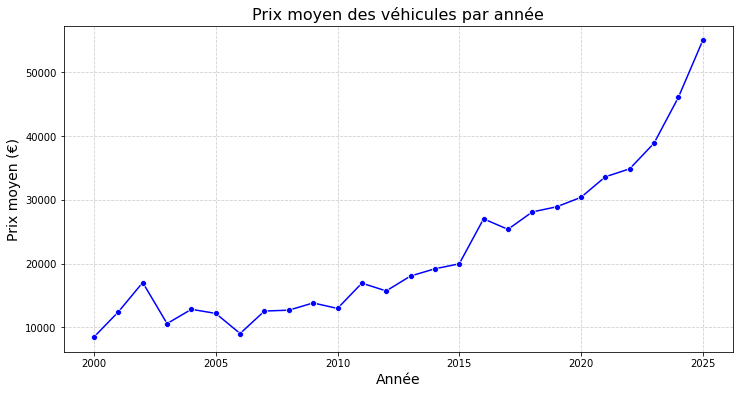

In [138]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculer le prix moyen par année
prix_par_annee = df.groupby('Annee')['Prix €'].mean()

# Créer la figure
plt.figure(figsize=(12, 6))

# Tracer le graphique
sns.lineplot(x=prix_par_annee.index, y=prix_par_annee.values, marker='o', color='blue')

# Ajouter des titres et des labels
plt.title("Prix moyen des véhicules par année", fontsize=16)
plt.xlabel("Année", fontsize=14)
plt.ylabel("Prix moyen (€)", fontsize=14)

# Ajouter une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.6)

# Afficher le graphique
plt.show()

In [139]:
df

,Carrosserie,Etat,Sieges,Portes,Annee,Transmission,Carburant,Couleur_originale,Type_peinture,Couleur_interieur,Prix €,Kilometrage_km,Puissance_CH,Cylindrée_cm³,Garantie_mois,Marque_Mercedes-Benz
0,Break,Occasion,5,5,2010,0,1.0,Gris,Métallisé,Gris,1100,247570,75,0,0,1
33,Cabriolet,Occasion,4,2,2014,1,1.0,NOIR,NON,NON,38490,26800,256,987,12,1
76,Berline,Occasion,5,4,2006,1,1.0,NON,Autres,NON,6000,196000,185,222,0,1
92,Autres,Occasion,0,2,2018,1,0.0,Blanc,NON,NON,34900,100300,0,0,0,1
126,Autres,Occasion,0,5,2019,1,0.0,Gris,NON,NON,30990,48195,190,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10223,Cabriolet,Occasion,0,2,2006,1,0.0,Vert,NON,NON,22990,85000,258,996,6,0
10225,Autres,Occasion,0,5,2018,1,1.0,NON,NON,NON,39990,78000,0,0,0,0
10226,Coupé,Occasion,0,2,2008,0,0.0,Noir,NON,NON,20990,82500,272,996,0,0
10232,Coupé,Occasion,5,4,2019,1,0.0,Carbonschwarz,Métallisé,NON,61900,95900,538,395,24,0


C:\Users\dell\AppData\Local\Temp\ipykernel_7272\192965974.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prix_moyen_par_portes.index, y=prix_moyen_par_portes.values, palette="viridis")


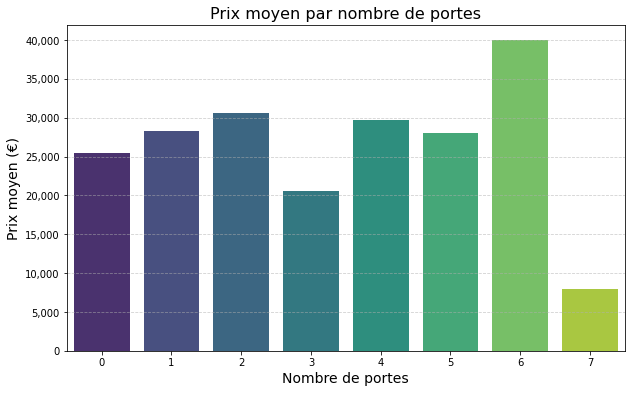

In [140]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculer le prix moyen par nombre de portes
prix_moyen_par_portes = df.groupby('Portes')['Prix €'].mean()

# Créer la figure
plt.figure(figsize=(10, 6))

# Tracer un graphique en barres
sns.barplot(x=prix_moyen_par_portes.index, y=prix_moyen_par_portes.values, palette="viridis")

# Ajouter des titres et des labels
plt.title("Prix moyen par nombre de portes", fontsize=16)
plt.xlabel("Nombre de portes", fontsize=14)
plt.ylabel("Prix moyen (€)", fontsize=14)

# Formatter l'axe des y pour éviter la notation scientifique
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Afficher le graphique
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

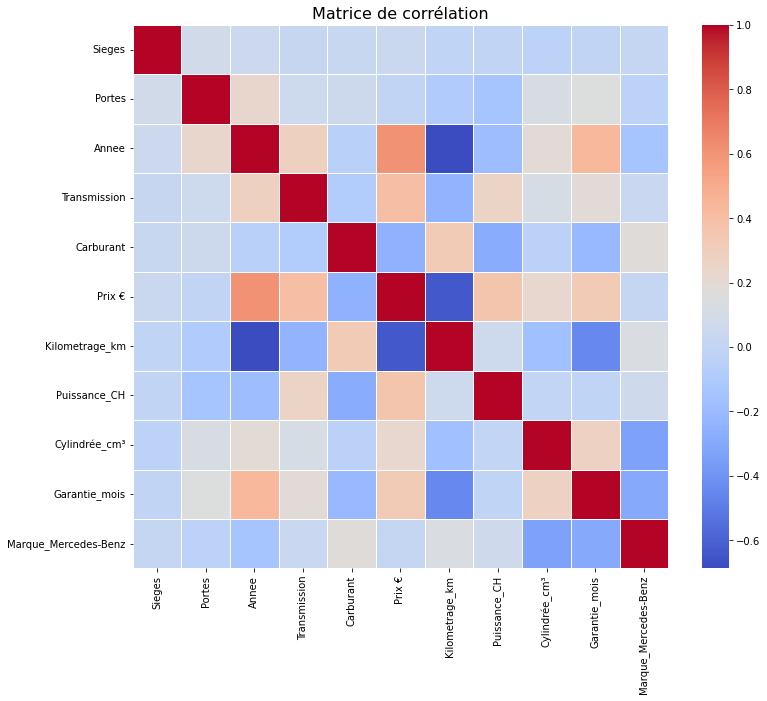

In [141]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculer la matrice de corrélation en excluant les colonnes non numériques
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Créer une figure pour le heatmap
plt.figure(figsize=(12, 10))

# Tracer le heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Ajouter un titre
plt.title("Matrice de corrélation", fontsize=16)

# Afficher le graphique
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_7272\468245769.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.index.str.replace('Marque', ''), y=top_models.values, palette="viridis")


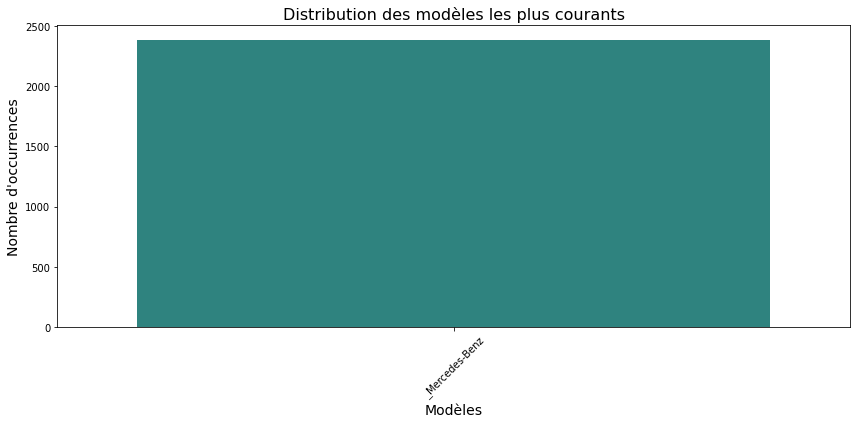

In [142]:
import seaborn as sns

import matplotlib.pyplot as plt

# Compter les occurrences des modèles principaux
model_counts = df.filter(like='Marque').sum().sort_values(ascending=False)

# Sélectionner les 10 modèles les plus courants
top_models = model_counts.head(10)

# Créer un graphique en barres
plt.figure(figsize=(12, 6))
sns.barplot(x=top_models.index.str.replace('Marque', ''), y=top_models.values, palette="viridis")

# Ajouter des titres et des labels
plt.title("Distribution des modèles les plus courants", fontsize=16)
plt.xlabel("Modèles", fontsize=14)
plt.ylabel("Nombre d'occurrences", fontsize=14)

# Rotation des labels pour une meilleure lisibilité
plt.xticks(rotation=45)

# Afficher le graphique
plt.tight_layout()
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_7272\2418542645.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prix_par_garantie.index, y=prix_par_garantie.values, palette="viridis")


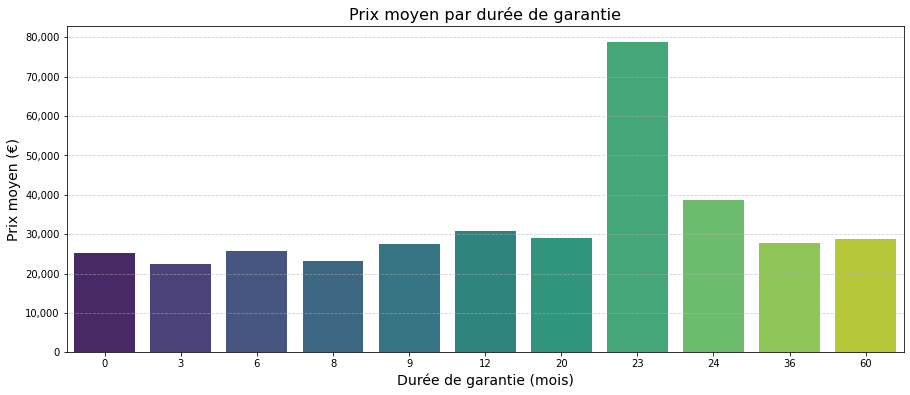

In [143]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculer le prix moyen par garantie
prix_par_garantie = df.groupby('Garantie_mois')['Prix €'].mean()

# Créer la figure
plt.figure(figsize=(15, 6))

# Tracer un graphique en barres
sns.barplot(x=prix_par_garantie.index, y=prix_par_garantie.values, palette="viridis")

# Ajouter des titres et des labels
plt.title("Prix moyen par durée de garantie", fontsize=16)
plt.xlabel("Durée de garantie (mois)", fontsize=14)
plt.ylabel("Prix moyen (€)", fontsize=14)

# Formatter l'axe des y pour éviter la notation scientifique
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Afficher le graphique
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [144]:
from sklearn.preprocessing import StandardScaler

# # Colonnes numériques à standardiser
# numerical_features = ['Kilometrage', 'Annee', 'puissance_ch', 'Garantie (mois)', 
#                       'prix_moyen_marque', 'prix_moyen_serie', 'kilometrage_moyen_marque', 
#                       'age_vehicule', 'km_annuel_moyen', 'valeur_relative_marque']

# # Initialiser le scaler
# scaler = StandardScaler()

# # Appliquer la standardisation
# df_gen_scaled = df_gen.copy()
# df_gen_scaled[numerical_features] = scaler.fit_transform(df_gen[numerical_features])

# # Afficher les premières lignes pour vérifier
# df_gen_scaled.head()

# entrainement du modele

## xgboost

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

In [146]:

# Définir la variable cible (prix) et les caractéristiques
y = df['Prix €']

In [147]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from datetime import datetime

# 1. Création des features dérivées
df['age_vehicule'] = datetime.now().year - df['Annee']
df['km_annuel_moyen'] = df['Kilometrage_km'] / df['age_vehicule'].clip(lower=1)
df['prix_moyen_marque'] = df.groupby('Marque_Mercedes-Benz')['Prix €'].transform('mean')
df['puissance_kw'] = df['Puissance_CH'] * 0.7355

# 2. Séparation des features et target
X = df.drop('Prix €', axis=1)
y = df['Prix €']

# 3. Définition des colonnes par type
numerical_features = ['Sieges', 'Portes', 'Annee', 'Kilometrage_km', 'Puissance_CH',
                     'Garantie_mois', 'age_vehicule', 'km_annuel_moyen', 
                     'prix_moyen_marque', 'puissance_kw', 'Cylindrée_cm³']

categorical_features = ['Etat', 'Transmission', 'Carburant', 'Carrosserie', 
                       'Marque_Mercedes-Benz']

# 4. Préprocessing avec ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Création du pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, enable_categorical=False))
])

# 6. Paramètres pour GridSearch (simplifiés)
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.01, 0.1]
}

# 7. Configuration de GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, 
                         cv=3, 
                         scoring='neg_mean_squared_error',
                         verbose=1,
                         n_jobs=-1)

# 8. Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Exécution de la GridSearch
grid_search.fit(X_train, y_train)

# 10. Résultats
print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur score (RMSE):", (-grid_search.best_score_)**0.5)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs paramètres: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
Meilleur score (RMSE): 5656.660714328443


In [148]:
# Diviser les données en ensembles d'entraînement et de test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [149]:

# Standardisation des variables numériques
# (Cette étape est facultative pour les arbres de décision mais peut être utile pour XGBoost)
scaler = StandardScaler()
numerical_features = ['Kilometrage', 'Annee', 'puissance_kw', 'puissance_ch', 
                      'prix_moyen_marque', 'prix_moyen_serie', 'kilometrage_moyen_marque', 
                      'age_vehicule', 'km_annuel_moyen']

In [152]:
# Créer une copie pour éviter les avertissements SettingWithCopyWarning
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Appliquer le scaling uniquement aux variables numériques
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

X_train_scaled[['Kilometrage', 'Annee', 'puissance_kw', 'puissance_ch', 
                      'prix_moyen_marque', 'prix_moyen_serie', 'kilometrage_moyen_marque', 
                      'age_vehicule', 'km_annuel_moyen']].head()

KeyError: "['Kilometrage', 'puissance_ch', 'prix_moyen_serie', 'kilometrage_moyen_marque'] not in index"

In [ ]:

# Initialiser le modèle   régression XGBoost (Extreme Gradient Boosting)
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)


In [ ]:

# Paramètres à tester pour l'optimisation
xgb_param_grid = {
    'n_estimators': [100, 200, 300], #n_estimators (Nombre d'arbres)
    'learning_rate': [0.01, 0.05, 0.1], #learning_rate (Taux d'apprentissage)
    'max_depth': [3, 5, 7],#max_depth (Profondeur maximale de l'arbre)
    'min_child_weight': [1, 3, 5],#min_child_weight (Poids minimum des enfants)
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}


In [ ]:

# Recherche par grille avec validation croisée
# Note: Cette opération peut prendre du temps, vous pouvez réduire le nombre de paramètres à tester
xgb_grid_search = GridSearchCV(xgb_model, xgb_param_grid, 
                              cv=5, scoring='neg_mean_squared_error', 
                              verbose=1, n_jobs=-1)

# Entraîner le modèle avec recherche des meilleurs hyperparamètres
xgb_grid_search.fit(X_train_scaled, y_train)


NameError: name 'X_train_scaled' is not defined

In [ ]:

# Meilleurs paramètres trouvés
print("\nMeilleurs paramètres pour XGBoost:")
print(xgb_grid_search.best_params_)




Meilleurs paramètres pour XGBoost:
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.7}


In [ ]:
# Utiliser le meilleur modèle
best_xgb_model = xgb_grid_search.best_estimator_



In [ ]:
# Prédictions
xgb_y_pred = best_xgb_model.predict(X_test_scaled)



In [ ]:
# Évaluation du modèle XGBoost
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("\nÉvaluation du modèle XGBoost:")
print(f"MSE: {xgb_mse:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"R² Score: {xgb_r2:.4f}")



Évaluation du modèle XGBoost:
MSE: 6678659357.99
RMSE: 81723.07
MAE: 14207.45
R² Score: 0.0860


 XGBoost présente un RMSE et un MAE relativement élevés, et surtout un R² très faible. Cela suggère que le modèle ne parvient pas à capturer suffisamment l'information présente dans vos données pour faire des prédictions précises

In [ ]:

# Caractéristiques importantes pour XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nImportance des caractéristiques (XGBoost):")
print(xgb_feature_importance.head(10))


Importance des caractéristiques (XGBoost):
                   Feature  Importance
20  valeur_relative_marque    0.653673
14  price_category_encoded    0.284225
16        prix_moyen_serie    0.015287
15       prix_moyen_marque    0.010591
3                   Portes    0.010470
18            age_vehicule    0.006217
7                Carburant    0.004955
5                    Annee    0.002888
8             puissance_kw    0.002098
6             Transmission    0.001437


## 2.Modèle d'Arbre de Décision

In [ ]:
# Initialiser le modèle
dt_model = DecisionTreeRegressor(random_state=42)


In [ ]:
# Paramètres à tester pour l'optimisation
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}


In [ ]:


# Recherche par grille avec validation croisée
dt_grid_search = GridSearchCV(dt_model, dt_param_grid, 
                            cv=5, scoring='neg_mean_squared_error', 
                            verbose=1, n_jobs=-1)

# Entraîner le modèle avec recherche des meilleurs hyperparamètres
dt_grid_search.fit(X_train_scaled, y_train)

# Meilleurs paramètres trouvés
print("Meilleurs paramètres pour l'arbre de décision:")
print(dt_grid_search.best_params_)

# Utiliser le meilleur modèle
best_dt_model = dt_grid_search.best_estimator_

# Prédictions
dt_y_pred = best_dt_model.predict(X_test_scaled)

# Évaluation du modèle d'arbre de décision
dt_mse = mean_squared_error(y_test, dt_y_pred)
dt_rmse = np.sqrt(dt_mse)
dt_mae = mean_absolute_error(y_test, dt_y_pred)
dt_r2 = r2_score(y_test, dt_y_pred)

print("\nÉvaluation du modèle d'arbre de décision:")
print(f"MSE: {dt_mse:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"MAE: {dt_mae:.2f}")
print(f"R² Score: {dt_r2:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Meilleurs paramètres pour l'arbre de décision:
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Évaluation du modèle d'arbre de décision:
MSE: 6545375588.67
RMSE: 80903.50
MAE: 14160.40
R² Score: 0.1042


In [ ]:

# Caractéristiques importantes pour l'arbre de décision
dt_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nImportance des caractéristiques (Arbre de décision):")
print(dt_feature_importance.head(10))



Importance des caractéristiques (Arbre de décision):
                   Feature  Importance
20  valeur_relative_marque    0.869299
14  price_category_encoded    0.102909
16        prix_moyen_serie    0.016596
4              Kilometrage    0.002596
10         Garantie (mois)    0.002321
5                    Annee    0.001997
8             puissance_kw    0.001492
19         km_annuel_moyen    0.000695
15       prix_moyen_marque    0.000487
0              Carrosserie    0.000437


In [ ]:
# 4. Comparaison des modèles
# -------------------------

# Créer un DataFrame pour comparer les prédictions
comparison_df = pd.DataFrame({
    'Prix réel': y_test,
    'Prédiction Arbre de Décision': dt_y_pred,
    'Prédiction XGBoost': xgb_y_pred,
    'Erreur Arbre de Décision': y_test - dt_y_pred,
    'Erreur XGBoost': y_test - xgb_y_pred
})

# Calculer l'erreur relative en pourcentage
comparison_df['Erreur relative Arbre (%)'] = (comparison_df['Erreur Arbre de Décision'] / comparison_df['Prix réel']) * 100
comparison_df['Erreur relative XGBoost (%)'] = (comparison_df['Erreur XGBoost'] / comparison_df['Prix réel']) * 100

# Afficher les premières lignes du DataFrame de comparaison
print("\nComparaison des prédictions:")
print(comparison_df.head())



Comparaison des prédictions:
     Prix réel  Prédiction Arbre de Décision  Prédiction XGBoost  \
139      11490                       10990.0        12348.667969   
473      11900                       12890.0        12228.784180   
74        9900                        8990.0         7425.156738   
306       7990                        7990.0         8164.438477   
233      10990                       10890.0        11290.114258   

     Erreur Arbre de Décision  Erreur XGBoost  Erreur relative Arbre (%)  \
139                     500.0     -858.667969                   4.351610   
473                    -990.0     -328.784180                  -8.319328   
74                      910.0     2474.843262                   9.191919   
306                       0.0     -174.438477                   0.000000   
233                     100.0     -300.114258                   0.909918   

     Erreur relative XGBoost (%)  
139                    -7.473176  
473                    -2.762892  

In [ ]:






# Résumé des erreurs relatives
print("\nRésumé des erreurs relatives (%):")
print(comparison_df[['Erreur relative Arbre (%)', 'Erreur relative XGBoost (%)']].describe())



Résumé des erreurs relatives (%):
       Erreur relative Arbre (%)  Erreur relative XGBoost (%)
count                  58.000000                    58.000000
mean                    3.722443                     3.002654
std                    22.767971                    20.798853
min                   -66.889632                   -35.534423
25%                    -7.016905                    -5.865602
50%                     0.000000                     1.370055
75%                     9.037782                     9.009332
max                    92.660407                    93.616947


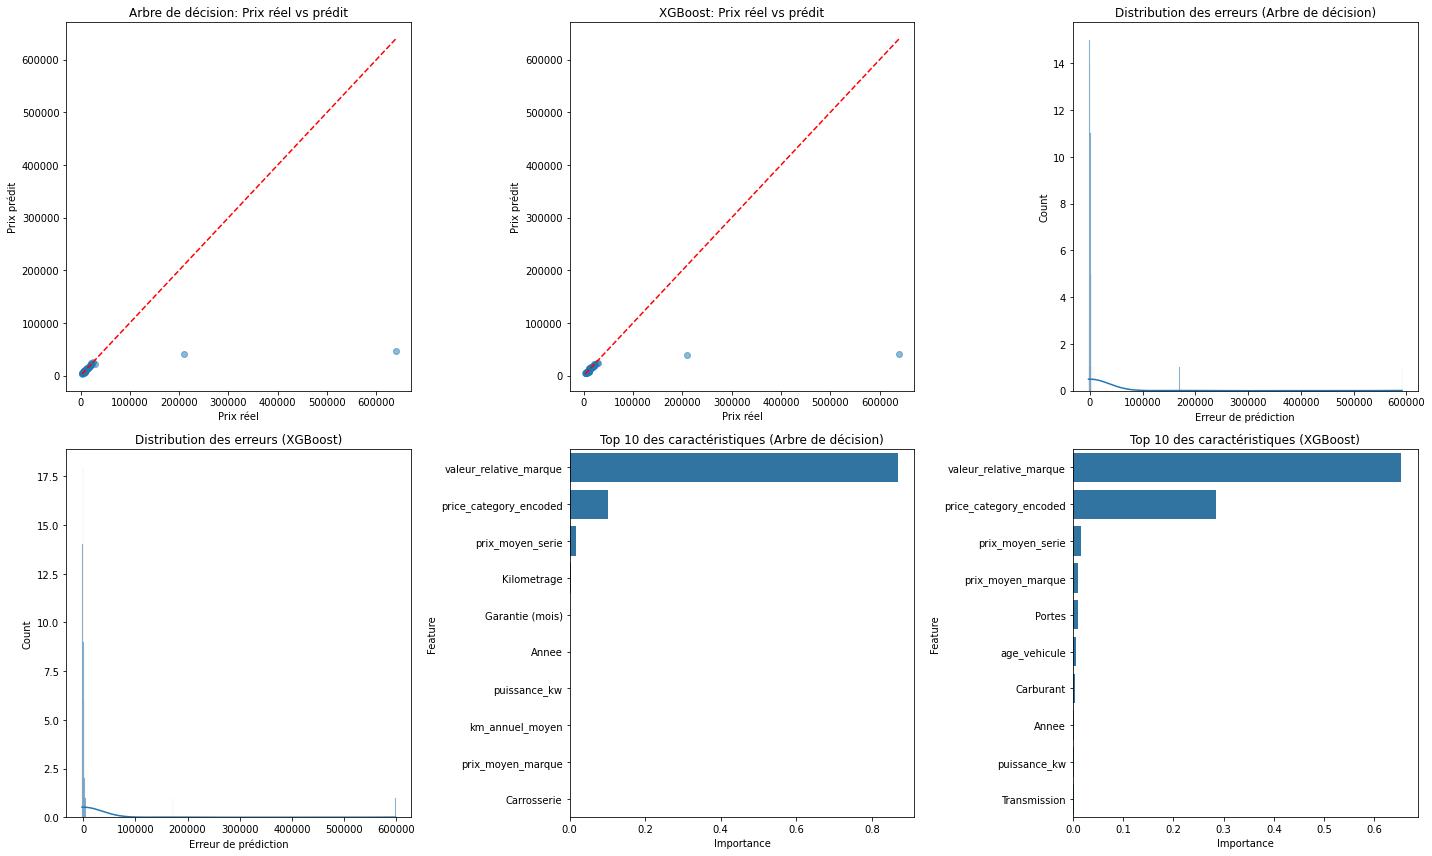

In [ ]:

# 5. Visualisation des résultats
# ----------------------------
from matplotlib import pyplot as plt
# Créer une figure avec plusieurs sous-graphiques
plt.figure(figsize=(20, 12))

# 1. Comparaison des prix réels vs prédits (Arbre de décision)
plt.subplot(2, 3, 1)
if 'y_test' in locals() and 'dt_y_pred' in locals():
	plt.scatter(y_test, dt_y_pred, alpha=0.5)
	plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
	plt.xlabel('Prix réel')
	plt.ylabel('Prix prédit')
	plt.title('Arbre de décision: Prix réel vs prédit')
else:
	print("Error: 'y_test' or 'dt_y_pred' is not defined. Please ensure the necessary cells are executed.")

# 2. Comparaison des prix réels vs prédits (XGBoost)
plt.subplot(2, 3, 2)
plt.scatter(y_test, xgb_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')
plt.title('XGBoost: Prix réel vs prédit')

# 3. Distribution des erreurs (Arbre de décision)
plt.subplot(2, 3, 3)
sns.histplot(comparison_df['Erreur Arbre de Décision'], kde=True)
plt.xlabel('Erreur de prédiction')
plt.title('Distribution des erreurs (Arbre de décision)')

# 4. Distribution des erreurs (XGBoost)
plt.subplot(2, 3, 4)
sns.histplot(comparison_df['Erreur XGBoost'], kde=True)
plt.xlabel('Erreur de prédiction')
plt.title('Distribution des erreurs (XGBoost)')

# 5. Top 10 des caractéristiques importantes (Arbre de décision)
plt.subplot(2, 3, 5)
sns.barplot(x='Importance', y='Feature', data=dt_feature_importance.head(10))
plt.title('Top 10 des caractéristiques (Arbre de décision)')

# 6. Top 10 des caractéristiques importantes (XGBoost)
plt.subplot(2, 3, 6)
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance.head(10))
plt.title('Top 10 des caractéristiques (XGBoost)')

plt.tight_layout()
plt.savefig('comparaison_modeles.png')
plt.show()


In [ ]:

# 6. Sauvegarder les modèles pour une utilisation future
# ----------------------------------------------------

import joblib

# Sauvegarder les modèles
joblib.dump(best_dt_model, 'decision_tree_model.pkl')
joblib.dump(best_xgb_model, 'xgboost_model.pkl')

# Sauvegarder le scaler pour standardiser les futures données
joblib.dump(scaler, 'scaler.pkl')

print("\nLes modèles ont été sauvegardés avec succès!")



Les modèles ont été sauvegardés avec succès!


In [ ]:

# 7. Fonction pour prédire le prix d'un nouveau véhicule
# ----------------------------------------------------

def predict_vehicle_price(model, new_vehicle_data, scaler=None, numerical_features=None):
    """
    Prédit le prix d'un nouveau véhicule en utilisant le modèle entraîné.
    
    Args:
        model: Le modèle entraîné (Arbre de décision ou XGBoost)
        new_vehicle_data: DataFrame avec les caractéristiques du nouveau véhicule
        scaler: Objet StandardScaler utilisé pour normaliser les données
        numerical_features: Liste des colonnes numériques à normaliser
        
    Returns:
        Le prix prédit pour le véhicule
    """
    # Si un scaler est fourni, appliquer la standardisation aux caractéristiques numériques
    if scaler is not None and numerical_features is not None:
        new_vehicle_data_scaled = new_vehicle_data.copy()
        new_vehicle_data_scaled[numerical_features] = scaler.transform(new_vehicle_data[numerical_features])
        return model.predict(new_vehicle_data_scaled)[0]
    else:
        return model.predict(new_vehicle_data)[0]

# Exemple d'utilisation avec un nouveau véhicule
print("\nExemple de prédiction pour un nouveau véhicule:")

# Créer un DataFrame pour un nouveau véhicule (avec les mêmes colonnes que celles utilisées pour l'entraînement)
# Remarque: Remplacez ces valeurs par celles d'un véhicule réel
new_vehicle = pd.DataFrame({
    'Carrosserie': [1],
    'Etat': [2],
    'Sieges': [5],
    'Portes': [5],
    'Kilometrage': [800000],
    'Annee': [2009],
    'Transmission': [1],  # 0 pour manuelle, 1 pour automatique par exemple
    'Carburant': [2],     # 0 pour essence, 1 pour diesel, 2 pour hybride par exemple
    'puissance_kw': [110],
    'puissance_ch': [150],
    'Garantie (mois)': [6],
    'marque_encoded': [5],  # Dépend de votre encodage
    'serie_encoded': [12],  # Dépend de votre encodage
    'body_category_encoded': [2],  # 1 pour SUV par exemple
    'price_category_encoded': [2],  # 2 pour Mid-range par exemple
    'prix_moyen_marque': [25000],
    'prix_moyen_serie': [22000],
    'kilometrage_moyen_marque': [900000],
    'age_vehicule': [17],
    'km_annuel_moyen': [114298.57],  # 80000/7
    'valeur_relative_marque': [0.9]  # Le véhicule vaut 90% du prix moyen de sa marque
})

# Prédire le prix avec les deux modèles
predicted_price_dt = predict_vehicle_price(best_dt_model, new_vehicle, scaler, numerical_features)
predicted_price_xgb = predict_vehicle_price(best_xgb_model, new_vehicle, scaler, numerical_features)

print(f"Prix prédit par l'arbre de décision: {predicted_price_dt:.2f} €")
print(f"Prix prédit par XGBoost: {predicted_price_xgb:.2f} €")
print(f"Prix moyen prédit: {(predicted_price_dt + predicted_price_xgb) / 2:.2f} €")


Exemple de prédiction pour un nouveau véhicule:
Prix prédit par l'arbre de décision: 24990.00 €
Prix prédit par XGBoost: 23417.98 €
Prix moyen prédit: 24203.99 €
